1. Data preprocessing

In [265]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

### filtering OUT columns eg. etl, htl = not training on them = standardising them

df = df[['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF', 'JV_hysteresis_index',
        'Perovskite_band_gap.1', 'JV_default_PCE', 'Stability_PCE_end_of_experiment']]

# Calculate PCE: (Jsc × Voc × FF) / 1 (assume 'power in' = 1)
df['Calculated_PCE'] = (df['JV_default_Jsc'] * df['JV_default_Voc'] * df['JV_default_FF']) 

# # Display the first few rows
# print(df[['JV_default_Jsc', 'JV_default_Voc', 'JV_default_FF', 'Calculated_PCE', 'JV_default_PCE']].head())

RF and RR models - predicting band gap and PCE from perovskite composition and other layers.
*Note - I have removed stability as a target as it is [literally impossible]

Without FF, Voc and Jsc:

the same as above but nicer formatting:


Model Performance Metrics:
              Model                 Target      R2    RMSE   NRMSE  R-value
0  Ridge Regression  Perovskite_band_gap.1  0.8651  0.0341  0.9301   0.0348
1  Ridge Regression         JV_default_PCE  0.0898  4.3391  0.3042   0.1963
2     Random Forest  Perovskite_band_gap.1  0.8651  0.0341  0.9301   0.0348
3     Random Forest         JV_default_PCE  0.0898  4.3391  0.3042   0.1963

Model Performance Metrics:
               Model                 Target      R2    RMSE   NRMSE  R-value
0  Ridge Regression  Perovskite_band_gap.1  0.8651  0.0341  0.9301   0.0348
1  Ridge Regression         JV_default_PCE  0.0898  4.3391  0.3042   0.1963
2     Random Forest  Perovskite_band_gap.1  0.8651  0.0341  0.9301   0.0348
3     Random Forest         JV_default_PCE  0.0898  4.3391  0.3042   0.1963


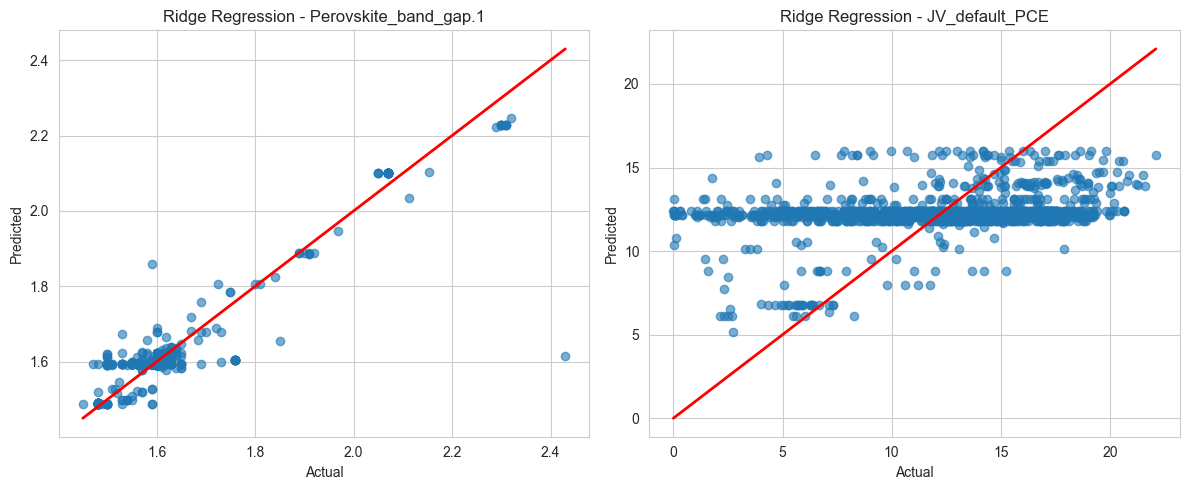

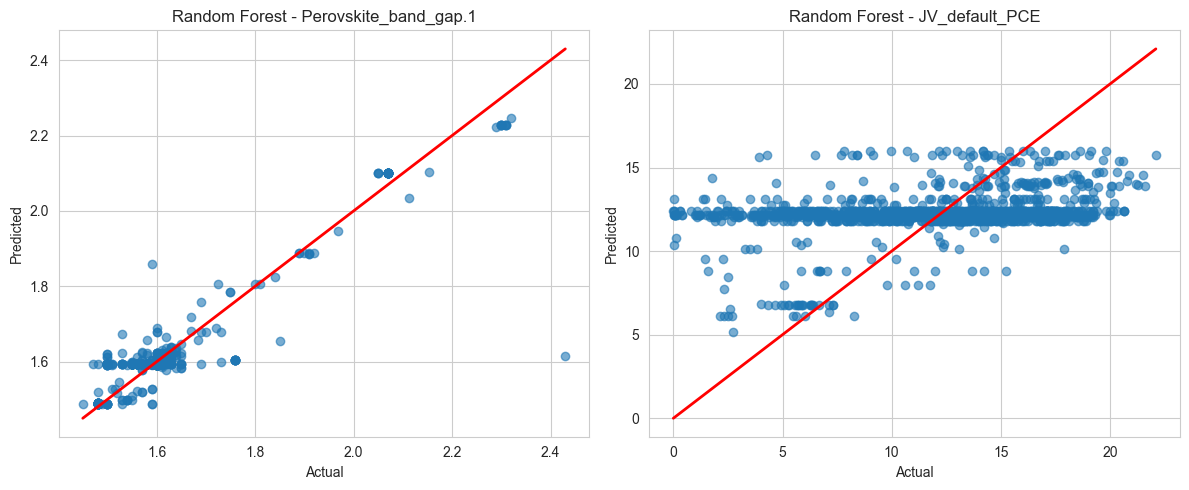

,Model,Target,R2,RMSE,NRMSE,R-value
0,Ridge Regression,Perovskite_band_gap.1,0.8651,0.0341,0.9301,0.0348
1,Ridge Regression,JV_default_PCE,0.0898,4.3391,0.3042,0.1963
2,Random Forest,Perovskite_band_gap.1,0.8651,0.0341,0.9301,0.0348
3,Random Forest,JV_default_PCE,0.0898,4.3391,0.3042,0.1963


In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define target variables (band gap and PCE)
targets = ['Perovskite_band_gap.1', 'JV_default_PCE']

# Define features
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 'SLG|ITO', 'SLG|FTO', 'TiO2-c', 
            'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[targets], test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge Regression Model
# ridge = linear_model.LinearRegression()
# ridge.fit(X_train_scaled, y_train)
# y_pred_ridge = ridge.predict(X_test_scaled)
# Ridge Regression Model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Train Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Ensure y_pred_rf is a 2D array
y_pred_rf = np.array(y_pred_ridge) if len(y_pred_ridge.shape) == 1 else y_pred_ridge

# Function to calculate metrics
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(y_true, y_pred, model_name):
    results = []
    for i, target in enumerate(targets):
        rmse = np.sqrt(mean_squared_error(y_true[target], y_pred[:, i]))
        nrmse = rmse / (y_true[target].max() - y_true[target].min())  # Normalized RMSE
        r_value = np.corrcoef(y_true[target], y_pred[:, i])[0, 1]
        r2 = r2_score(y_true[target], y_pred[:, i])
        results.append([model_name, target, round(r2, 4), round(rmse, 4), round(r_value, 4), round(rmse / (y_true[target].max() - y_true[target].min()), 4)])
    
    return results

# Evaluate models and store results
ridge_results = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Create DataFrame for displaying results
# Define DataFrame columns
columns = ["Model", "Target", "R2", "RMSE", "NRMSE", "R-value"]

# Convert list to DataFrame
all_results = ridge_results + rf_results
results_df = pd.DataFrame(all_results, columns=columns)

# Display the results table
print("\nModel Performance Metrics:")
print(results_df)

# Display the results table
print("\nModel Performance Metrics:\n", results_df)


# Plot for Ridge Regression
def plot_predictions(y_test, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for i, target in enumerate(targets):
        axes[i].scatter(y_test[target], y_pred[:, i], alpha=0.6)
        axes[i].plot([y_test[target].min(), y_test[target].max()], [y_test[target].min(), y_test[target].max()], 'r', lw=2)
        axes[i].set_xlabel("Actual")
        axes[i].set_ylabel("Predicted")
        axes[i].set_title(f"{model_name} - {target}")
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_predictions(y_test, y_pred_ridge, "Ridge Regression")
plot_predictions(y_test, y_pred_rf, "Random Forest")

# Display the performance metrics table
results_df



XGBoost - predicting band gap and PCE from perovskite composition ONLY

In [272]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Define features and targets
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I']
targets =  ['Perovskite_band_gap.1', 'JV_default_PCE']

# Drop NaN values
df = df.dropna(subset=features + targets)

# Split dataset into train and test sets
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📌 Step 1: Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 📌 Step 2: Use GridSearchCV to find best hyperparameters for one target (e.g., PCE)
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train['JV_default_PCE'])

# Get best hyperparameters
best_params = grid_search.best_params_
print("🔥 Best Hyperparameters:", best_params)

# 📌 Step 3: Train final XGBoost models for all targets using best hyperparameters
xgb_models = {}
y_preds = {}

for target in targets:
    model = xgb.XGBRegressor(**best_params)  # Use the best params here
    model.fit(X_train, y_train[target])
    y_pred = model.predict(X_test)
    
    xgb_models[target] = model
    y_preds[target] = y_pred

# 📌 Step 4: Evaluate performance
print("📌 XGBoost Performance:")
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    nrmse = rmse / (y_true.max() - y_true.min())  # Normalized RMSE
    r_value, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"🔹 XGBoost {target} - RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}, R-value: {r_value:.2f}, R²: {r2:.2f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
🔥 Best Hyperparameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
📌 XGBoost Performance:
🔹 XGBoost Perovskite_band_gap.1 - RMSE: 0.03, NRMSE: 0.03, R-value: 0.94, R²: 0.89
🔹 XGBoost JV_default_PCE - RMSE: 4.28, NRMSE: 0.19, R-value: 0.34, R²: 0.11


c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Comparing predicted vs real values of band gap (from perovskite composition)

In [222]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure data is properly formatted
x = y_test['Perovskite_band_gap.1']  # Actual values
y = y_preds['Perovskite_band_gap.1']  # Predicted values

# Compute RMSE
rmse = mean_squared_error(x, y, squared=False)

# Compute R² Score
r2 = r2_score(x, y)

# Print results
print(f"📊 Model Performance Metrics:")
print(f"🔹 RMSE: {rmse:.4f} eV")
print(f"🔹 R² Score: {r2:.4f}")

# Create scatter plot with transparency
plt.scatter(x, y, color='blue', alpha=0.3, label="Predictions")  # Blue points with transparency

# Add diagonal reference line (ideal prediction)
plt.plot([min(x), max(x)], [min(x), max(x)], 'r-', label="Ideal Prediction")  # Ensures line covers full range

# add pearson correlation to the plot 
r_value, _ = pearsonr(x, y)
plt.text(1.5, 3.5, f"R² = {r2:.2f}", fontsize=12)

# Titles and labels
plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Predicted vs Actual Band Gap using Perovskite Composition")
plt.legend()

plt.show()


KeyError: 'Perovskite_band_gap.1'

Predicted vs Real PCE values - plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure data is properly formatted
x = y_test['JV_default_PCE']  # Actual values
y = y_preds['JV_default_PCE']  # Predicted values

# Compute RMSE
rmse = mean_squared_error(x, y, squared=False)

# Compute R² Score
r2 = r2_score(x, y)

# Print results
print(f"📊 Model Performance Metrics:")
print(f"🔹 RMSE: {rmse:.4f} eV")
print(f"🔹 R² Score: {r2:.4f}")

# Create scatter plot with transparency
plt.scatter(x, y, color='blue', alpha=0.3, label="Predictions")  # Blue points with transparency

# Add diagonal reference line (ideal prediction)
plt.plot([min(x), max(x)], [min(x), max(x)], 'r-', label="Ideal Prediction")  # Ensures line covers full range

# Titles and labels
plt.xlabel("Actual PCE (%)")
plt.ylabel("Predicted PCE (%)")
plt.title("Predicted vs Actual PCE using Perovskite Composition")
plt.legend()

plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [1672, 1609]

In [271]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure LaTeX-style font rendering
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Align actual and predicted values
x = y_test['JV_default_PCE']
y = y_preds['JV_default_PCE']

# Ensure both arrays have the same length
common_index = x.index.intersection(y.index)
x = x.loc[common_index]
y = y.loc[common_index]

# Convert to numpy arrays
x = x.to_numpy()
y = y.to_numpy()

# Compute RMSE and R²
rmse = mean_squared_error(x, y, squared=False)
r2 = r2_score(x, y)

# Create scatter plot with transparency
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', alpha=0.3, label="Predictions")

# Add diagonal reference line (ideal prediction)
plt.plot([min(x), max(x)], [min(x), max(x)], 'r--', label=r'$\text{Ideal Prediction}$')

# Titles and labels in LaTeX font
plt.title(r'\textbf{Predicted vs. Actual $\mathrm{PCE}$}', fontsize=14)
plt.xlabel(r'$\text{Actual PCE (\%)}$', fontsize=12)
plt.ylabel(r'$\text{Predicted PCE (\%)}$', fontsize=12)

# Add RMSE and R² annotations with LaTeX formatting
plt.text(0.05 * max(x), max(y) - 1, r'$\text{RMSE: } {:.4f} \, \text{eV}$'.format(rmse), fontsize=12, color='black')
plt.text(0.05 * max(x), max(y) - 1.5, r'$\text{R}^2 = {:.4f}$'.format(r2), fontsize=12, color='black')

plt.legend(prop={'size': 10})
plt.grid(True, linestyle='--', alpha=0.5)
plt.title(r'\textbf{Scatter Plot of Predicted vs Actual $\mathrm{PCE}$}', fontsize=14)

# Show plot
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score

def plot_regression_results(y_true, y_pred, cmap='viridis'):
    """
    Plots predicted vs true values for regression with density coloring (log scale).
   
    Parameters:
    - y_true: array-like, true values
    - y_pred: array-like, predicted values
    - cmap: str, colormap for density
    """
    plt.figure(figsize=(8, 6), dpi=150)

    r2_value = r2_score(y_true, y_pred)
   
    # Use LogNorm for log-scaled density visualization
    hb = plt.hexbin(y_true, y_pred, gridsize=10, cmap=cmap, mincnt=1, bins='log')

    # Add colorbar
    cb = plt.colorbar(hb)
    cb.set_label("Log Density")

    # Plot y = x line
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='y = x')

    # Labels and title
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")

    plt.title("XGBoost - Band gap Predictions vs True Values (Log Density)")
   
    # Add legend with R and R^2 scores
    plt.legend([f"R² = {r2_value:.2f}"], fontsize=16)
   
    plt.show()

# Example usage

plot_regression_results(x, y)

Determination of the best hyperparameters:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='r2', verbose=1)
grid_search.fit(X_train, y_train['JV_default_PCE'])

best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train final model with best hyperparameters
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train['JV_default_PCE'])


XGBoost - predicting PCE using perovskite composition, other layers (one-hot encoding) AND band gap:

In [ ]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Define new feature set
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
            'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 
            'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'Perovskite_band_gap.1', 'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF']

targets = ['JV_default_PCE']

# Drop NaN values
df = df.dropna(subset=features + targets)

# Split dataset
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and tune XGBoost models
best_models = {}
y_preds = {}

for target in targets:
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    
    grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train[target])
    
    best_model = grid_search.best_estimator_  # Get best model from tuning
    y_pred = best_model.predict(X_test)

    best_models[target] = best_model
    y_preds[target] = y_pred

# Evaluate performance
print("📌 Optimized XGBoost Performance:")
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    nrmse = rmse / (y_true.max() - y_true.min())  
    r_value, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"🔹 {target} - RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}, R-value: {r_value:.2f}, R²: {r2:.2f}")

# Show best hyperparameters
for target in targets:
    print(f"✅ Best Hyperparameters for {target}: {best_models[target].get_params()}")

📌 Optimized XGBoost Performance:
🔹 JV_default_PCE - RMSE: 4.23, NRMSE: 0.20, R-value: 0.40, R²: 0.16
✅ Best Hyperparameters for JV_default_PCE: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_method': None, 'validate_para

c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


📌 Optimized XGBoost Performance:
🔹 JV_default_PCE - RMSE: 0.85, NRMSE: 0.04, R-value: 0.98, R²: 0.97
✅ Best Hyperparameters for JV_default_PCE: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9, 'tree_method': None, 'validate_pa

c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


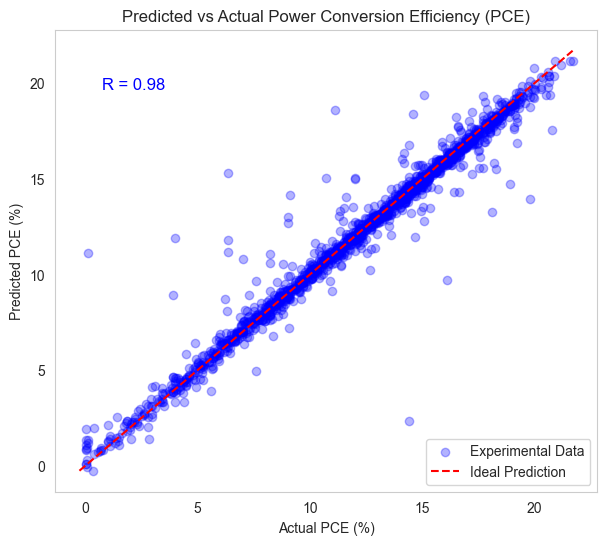

In [220]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# Define new feature set
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
            'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 
            'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'Perovskite_band_gap.1', 
            'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF']

targets = ['JV_default_PCE']

# Drop NaN values
df = df.dropna(subset=features + targets)

# Split dataset
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and tune XGBoost models
best_models = {}
y_preds = {}

for target in targets:
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    
    grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train[target])
    
    best_model = grid_search.best_estimator_  # Get best model from tuning
    y_pred = best_model.predict(X_test)

    best_models[target] = best_model
    y_preds[target] = y_pred

# Evaluate performance
print("📌 Optimized XGBoost Performance:")
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    nrmse = rmse / (y_true.max() - y_true.min())  
    r_value, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"🔹 {target} - RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}, R-value: {r_value:.2f}, R²: {r2:.2f}")

# Show best hyperparameters
for target in targets:
    print(f"✅ Best Hyperparameters for {target}: {best_models[target].get_params()}")

# Plot Real vs. Predicted PCE
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]

    plt.figure(figsize=(7, 6))
    plt.scatter(x=y_true, y=y_pred, color='blue', alpha=0.3, label="Experimental Data")


    # Add 1:1 line
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Prediction")

    # Labels and title
    plt.xlabel("Actual PCE (%)")
    plt.ylabel("Predicted PCE (%)")
    plt.title(f"Predicted vs Actual Power Conversion Efficiency (PCE)")
    plt.legend()

    # Add Pearson correlation in text
    plt.text(min_val + 1, max_val - 2, f"R = {r_value:.2f}", fontsize=12, color="blue")

    plt.grid(False)
    plt.show()

XGBoost - predicting band gap and PCE (using perovskite composition and other layers):

In [211]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import joblib

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# Define feature set (removing band gap since it's now a target)
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
            'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 
            'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'JV_default_FF', 'JV_default_Jsc', 'JV_default_Voc']

# Define targets (including band gap)
targets = ['Perovskite_band_gap.1', 'JV_default_PCE']

# Drop NaN values
df = df.dropna(subset=features)

# Split dataset
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and tune XGBoost models
best_models = {}
y_preds = {}

for target in targets:
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    
    grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train[target])
    
    best_model = grid_search.best_estimator_  # Get best model from tuning
    y_pred = best_model.predict(X_test)

    best_models[target] = best_model
    y_preds[target] = y_pred

# Evaluate performance
print("📌 Optimized XGBoost Performance:")
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    nrmse = rmse / (y_true.max() - y_true.min())  
    r_value, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"🔹 {target} - RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}, R-value: {r_value:.2f}, R²: {r2:.2f}")
    
    # Plot Predicted vs Actual values with specified styling
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, color='blue', alpha=0.3, label="Predictions")  # Blue points with transparency
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Perfect Prediction")  # Red dashed line
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Predicted vs. Actual for {target}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Show best hyperparameters
for target in targets:
    print(f"✅ Best Hyperparameters for {target}: {best_models[target].get_params()}")

# Save models to disk
    filename = f"best_xgb_{target}.pkl"
    joblib.dump(best_models[target], filename)
    print(f"✅ Model saved: {filename}")


KeyboardInterrupt: 

Shockley-Queisser approach - compare our band gap/PCE values to S-Q theoretical values:

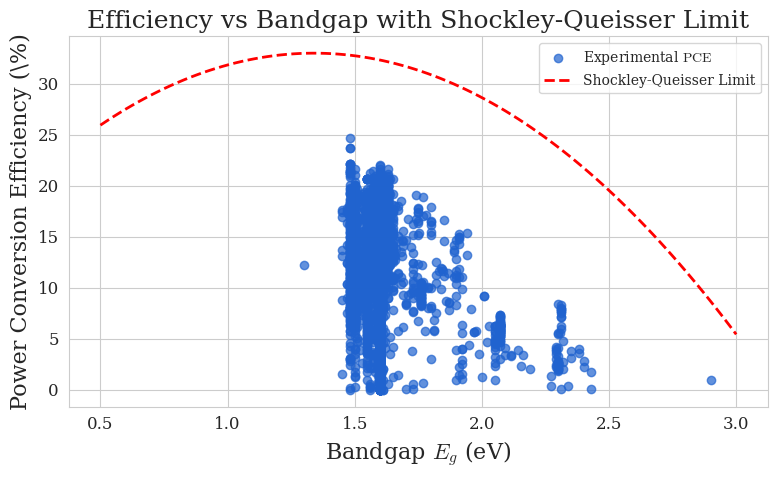

In [291]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# Enable nice font rendering
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.size': 14,
    'mathtext.fontset': 'cm'
})

# Example data
bandgap_data = df['Perovskite_band_gap.1']
pce_data = df['JV_default_PCE']

# Function to compute Shockley-Queisser limit
def compute_shockley_queisser(E_g):
    # Parabolic approximation centered at ~1.34 eV with max efficiency ~33%
    return 33 - 10 * (E_g - 1.34) ** 2

# Generate theoretical SQ limit curve
bandgaps = np.linspace(0.5, 3.0, 100)
sq_efficiencies = np.array([compute_shockley_queisser(E) for E in bandgaps])

# Create plot
plt.figure(figsize=(8, 5))

# Scatter plot for perovskite data with custom RGB color (dark cyan)
# RGB value as (0, 123, 167) normalized to [0,1]
plt.scatter(bandgap_data, pce_data, color=(32/255, 99/255, 207/255), 
            alpha=0.7, label=r'Experimental $\mathrm{PCE}$')

# Plot SQ limit curve with dashed red line
plt.plot(bandgaps, sq_efficiencies, 'r--', linewidth=2, label=r"Shockley-Queisser Limit")

# Set labels and title
plt.xlabel(r"Bandgap $E_g$ (eV)", fontsize=16)
plt.ylabel(r"Power Conversion Efficiency (\%)", fontsize=16)
plt.title(r"Efficiency vs Bandgap with Shockley-Queisser Limit", fontsize=18)

# Customize axis tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Position legend in the top right corner with small size
plt.legend(loc='upper right', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plot
plt.show()

📌 Optimized XGBoost Performance:
🔹 JV_default_FF - RMSE: 0.15, NRMSE: 0.03, R-value: 0.16, R²: 0.02
🔹 JV_default_Jsc - RMSE: 4.27, NRMSE: 0.17, R-value: 0.43, R²: 0.19
🔹 JV_default_Voc - RMSE: 0.12, NRMSE: 0.08, R-value: 0.36, R²: 0.12
🔹 Calculated PCE - RMSE: 4.33, R-value: 0.36, R²: 0.12


c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To cal

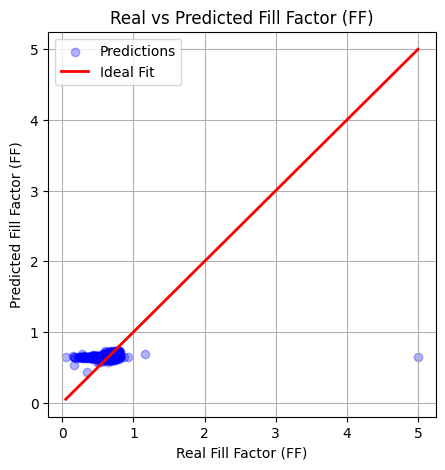

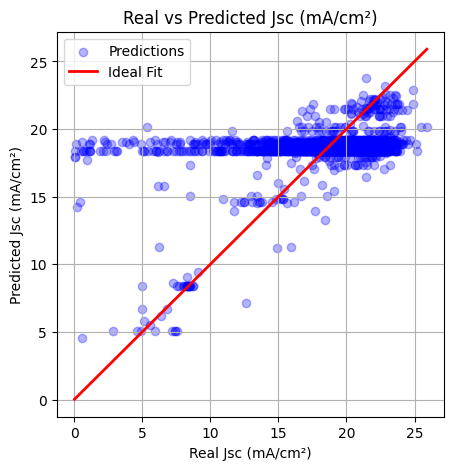

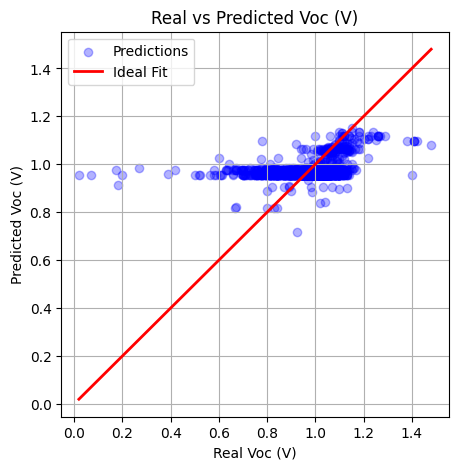

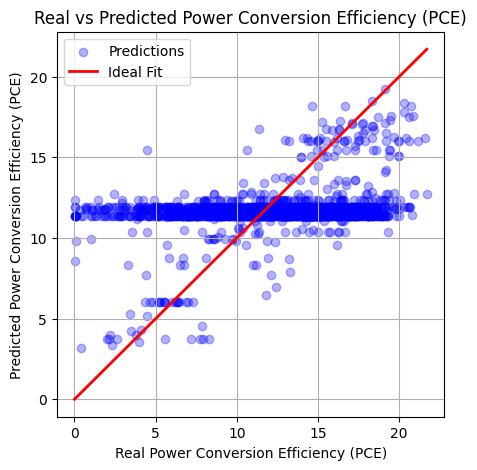

In [91]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Define new feature set
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
            'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 
            'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']

targets = ['JV_default_FF', 'JV_default_Jsc', 'JV_default_Voc']

# Drop NaN values
df = df.dropna(subset=features + targets + ['JV_default_PCE'])

# Split dataset
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and tune XGBoost models
best_models = {}
y_preds = {}

for target in targets:
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    
    grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train[target])
    
    best_model = grid_search.best_estimator_  # Get best model from tuning
    y_pred = best_model.predict(X_test)

    best_models[target] = best_model
    y_preds[target] = y_pred

# Convert predictions into a DataFrame
predictions_df = pd.DataFrame({
    'Predicted_FF': y_preds['JV_default_FF'],
    'Predicted_Jsc': y_preds['JV_default_Jsc'],
    'Predicted_Voc': y_preds['JV_default_Voc']
})

# Calculate the predicted PCE
predictions_df['Calculated_PCE'] = (
    predictions_df['Predicted_FF'] * predictions_df['Predicted_Jsc'] * predictions_df['Predicted_Voc']
)

# Extract real values for comparison
real_values_df = y_test.copy()
real_values_df['Real_PCE'] = df.loc[y_test.index, 'JV_default_PCE']

# Evaluate performance
print("📌 Optimized XGBoost Performance:")
for target in targets:
    y_true = y_test[target]
    y_pred = y_preds[target]
    
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    nrmse = rmse / (y_true.max() - y_true.min())  
    r_value, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"🔹 {target} - RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}, R-value: {r_value:.2f}, R²: {r2:.2f}")

# Calculate and evaluate PCE predictions
rmse_pce = mean_squared_error(real_values_df['Real_PCE'], predictions_df['Calculated_PCE'], squared=False)
r_value_pce, _ = pearsonr(real_values_df['Real_PCE'], predictions_df['Calculated_PCE'])
r2_pce = r2_score(real_values_df['Real_PCE'], predictions_df['Calculated_PCE'])

print(f"🔹 Calculated PCE - RMSE: {rmse_pce:.2f}, R-value: {r_value_pce:.2f}, R²: {r2_pce:.2f}")

# Function to plot real vs predicted values
def plot_real_vs_predicted(y_real, y_pred, label):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_real, y_pred, color='blue', alpha=0.3, label="Predictions")  
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r-', lw=2, label="Ideal Fit")
    plt.xlabel(f"Real {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"Real vs Predicted {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot real vs predicted for each target
plot_real_vs_predicted(y_test['JV_default_FF'], y_preds['JV_default_FF'], "Fill Factor (FF)")
plot_real_vs_predicted(y_test['JV_default_Jsc'], y_preds['JV_default_Jsc'], "Jsc (mA/cm²)")
plot_real_vs_predicted(y_test['JV_default_Voc'], y_preds['JV_default_Voc'], "Voc (V)")
plot_real_vs_predicted(real_values_df['Real_PCE'], predictions_df['Calculated_PCE'], "Power Conversion Efficiency (PCE)")

Feature importance - PCE:

In [252]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Define features and targets
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 'SLG|ITO', 'SLG|FTO', 
            'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'Perovskite_band_gap.1']
targets = ['JV_default_PCE']

# Drop NaN values
df = df.dropna(subset=features + targets)

# Split dataset into train and test sets
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
model.fit(X_train, y_train['JV_default_PCE'])  # Change to 'Perovskite_band_gap.1' to analyze band gap

# Get feature importance scores
importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance for PCE Prediction")
plt.gca().invert_yaxis()
plt.show()

# SHAP for better explainability 
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.initjs()

# SHAP Bar Plot (Feature Importance)
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.title("Feature Importance (SHAP Values)")  # Add title
plt.xlabel("Mean Absolute SHAP Value")  # Label x-axis
plt.ylabel("Features")  # Label y-axis
plt.show()

# SHAP Summary Plot (Distribution of SHAP Values)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test)
plt.title("SHAP Summary Plot")  # Add title
plt.xlabel("SHAP Value Impact")  # Label x-axis
plt.ylabel("Features")  # Label y-axis
plt.show()

KeyError: ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'Perovskite_band_gap.1', 'JV_default_PCE']

Feature importance - band gap:

In [253]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Define features and targets
features = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 'SLG|ITO', 'SLG|FTO', 
            'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']
targets = ['Perovskite_band_gap.1']

# Drop NaN values
df = df.dropna(subset=features + targets)

# Split dataset into train and test sets
X = df[features]
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
model.fit(X_train, y_train['Perovskite_band_gap.1'])  # Change to 'Perovskite_band_gap.1' to analyze band gap

# Get feature importance scores
importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance for Bandgap Prediction")
plt.gca().invert_yaxis()
plt.show()

# SHAP for better explainability 
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.initjs()

# SHAP Bar Plot (Feature Importance)
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.title("Feature Importance (SHAP Values)")  # Add title
plt.xlabel("Mean Absolute SHAP Value")  # Label x-axis
plt.ylabel("Features")  # Label y-axis
plt.show()

# SHAP Summary Plot (Distribution of SHAP Values)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test)
plt.title("SHAP Summary Plot")  # Add title
plt.xlabel("SHAP Value Impact")  # Label x-axis
plt.ylabel("Features")  # Label y-axis
plt.show()

KeyError: ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag', 'Perovskite_band_gap.1']